In [6]:
import pandas as pd

df = pd.read_csv("C:/Users/Sunil/Downloads/Dataset-Pyhton-001/Dataset/car_prices.csv")

In [7]:
# Shows first 5 records to understand structure
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [8]:
# Display data types & record count
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


(558837, 16)

In [10]:
# Count missing values in each column
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

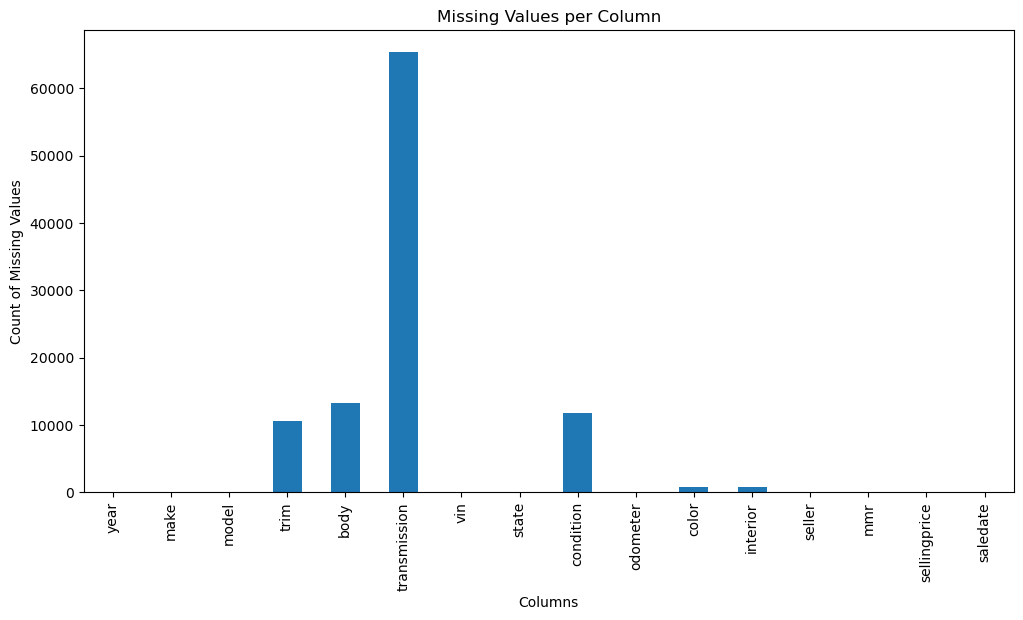

In [15]:
# Bar chart of missing values
import matplotlib.pyplot as plt

df.isnull().sum().plot(kind='bar', figsize=(12,6))
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Count of Missing Values")
plt.show()

In [16]:
# percentage of null values
null_percent = (df.isnull().mean()*100).sort_values(ascending=False)
print(null_percent)

transmission    11.694287
body             2.361154
condition        2.115107
trim             1.905922
color            0.134028
interior         0.134028
odometer         0.016821
mmr              0.006800
saledate         0.002147
sellingprice     0.002147
vin              0.000716
model            0.000000
state            0.000000
year             0.000000
make             0.000000
seller           0.000000
dtype: float64


In [20]:
# Replacement of null values
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])
df['body'] = df['body'].fillna(df['body'].mode()[0])
df['condition'] = df['condition'].fillna(df['condition'].median())
df['trim'] = df['trim'].fillna(df['trim'].mode()[0])
df['color'] = df['color'].fillna(df['color'].mode()[0])
df['interior'] = df['interior'].fillna(df['interior'].mode()[0])
df['odometer'] = df['odometer'].fillna(df['odometer'].median())
df['mmr'] = df['mmr'].fillna(df['mmr'].median())
df['saledate'] = df['saledate'].fillna(df['saledate'].mode()[0])
df['sellingprice'] = df['sellingprice'].fillna(df['sellingprice'].median())

In [21]:
# Numerical columns
num_cols = ['condition', 'odometer', 'mmr', 'sellingprice']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns
cat_cols = ['transmission', 'body', 'trim', 'color', 'interior']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Saledate
df['saledate'] = df['saledate'].fillna(df['saledate'].mode()[0])

In [22]:
# duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [26]:
# Average car price
avg_price = df['sellingprice'].mean()

# Minimum car price
min_price = df['sellingprice'].min()

# Maximum car price
max_price = df['sellingprice'].max()

avg_price, min_price, max_price

(np.float64(13611.326356343621), 1.0, 230000.0)

In [30]:
# List all unique colors of cars
df['color'].unique()

array(['white', 'gray', 'black', 'red', 'silver', 'blue', 'brown',
       'beige', 'purple', 'burgundy', '—', 'gold', 'yellow', 'green',
       'charcoal', 'orange', 'off-white', 'turquoise', 'pink', 'lime',
       '4802', '9410', '1167', '2172', '14872', '12655', '15719', '6388',
       '16633', '11034', '2711', '6864', '339', '18384', '9887', '9837',
       '20379', '20627', '721', '6158', '2817', '5705', '18561', '2846',
       '9562', '5001'], dtype=object)

In [31]:
# Number of unique car brands
df['make'].nunique()

96

In [32]:
# Number of unique car models
df['model'].nunique() 

973

In [34]:
# cars having selling prices greater than $165000
df[df['sellingprice'] > 165000]

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


In [35]:
#  top 5 most frequently sold car models
df['model'].value_counts().head(5)

model
Altima    29748
F-150     14479
Fusion    12946
Camry     12545
Escape    11861
Name: count, dtype: int64

In [37]:
# average selling price of cars by brand 
df.groupby('make')['sellingprice'].mean()

make
Acura           14017.268260
Aston Martin    54812.000000
Audi            19915.432782
BMW             21441.895748
Bentley         74367.672414
                    ...     
subaru           3710.416667
suzuki           4810.000000
toyota           7339.105263
volkswagen       6145.833333
vw              13672.916667
Name: sellingprice, Length: 96, dtype: float64

In [38]:
# minimum selling price of cars for each interior
df.groupby('interior')['sellingprice'].min()

interior
beige         100.0
black           1.0
blue          150.0
brown         200.0
burgundy      175.0
gold          250.0
gray            1.0
green         100.0
off-white     900.0
orange       1200.0
purple        200.0
red           200.0
silver        150.0
tan           100.0
white         350.0
yellow       3100.0
—             150.0
Name: sellingprice, dtype: float64

In [39]:
# highest odometer reading per year from highest to lowest order
df.groupby('year')['odometer'].max().sort_values(ascending=False)

year
1997    999999.0
1996    999999.0
2014    999999.0
2013    999999.0
1998    999999.0
1999    999999.0
1993    999999.0
2010    999999.0
2009    999999.0
2012    999999.0
2008    999999.0
2007    999999.0
2005    999999.0
2006    999999.0
2004    999999.0
2003    999999.0
2002    999999.0
2001    999999.0
2011    999999.0
2000    462579.0
1995    396793.0
1992    379307.0
1994    356402.0
1991    274149.0
1986    273327.0
1990    265498.0
1988    241751.0
1987    230946.0
1989    218052.0
1984    170799.0
1985    121644.0
2015    100454.0
1982     85738.0
1983     42697.0
Name: odometer, dtype: float64

In [43]:
# car age column
df['car_age'] = 2025 - df['year']

In [44]:
# number of cars having a condition greater than or equal to 48 and odometer greater than 90000
df_filtered = df[(df['condition'] >= 48) & (df['odometer'] > 90000)]
df_filtered.shape[0]

746

In [45]:
# state consistently has higher car prices for newer cars(year>2013)
# cars with year > 2013
newer_cars = df[df['year'] > 2013]
# average selling price per state
state_prices = newer_cars.groupby('state')['sellingprice'].mean()
state_prices.sort_values(ascending=False)

state
oh                   28020.221053
ab                   25204.255319
nj                   24237.063973
on                   22962.560386
qc                   22722.938144
                         ...     
3vwd17aj5fm225953    13200.000000
3vwd17aj8fm239622    13200.000000
3vwd17aj3fm276741    13200.000000
3vwd17aj4fm201708    13200.000000
ok                   10600.000000
Name: sellingprice, Length: 64, dtype: float64

In [47]:
# lowest average price (value for money cars)
threshold = df['condition'].quantile(0.80)
excellent_cars = df[df['condition'] >= threshold]
# average selling price per make
value_for_money = excellent_cars.groupby('make')['sellingprice'].mean()
# lowest average price (best value for money)
value_for_money.sort_values().head(10)

make
Isuzu         1125.000000
Oldsmobile    1910.000000
honda         4233.333333
Saturn        5700.406504
subaru        6200.000000
chrysler      6225.000000
smart         6835.759494
mazda         7275.000000
Pontiac       7686.824324
Saab          7711.111111
Name: sellingprice, dtype: float64

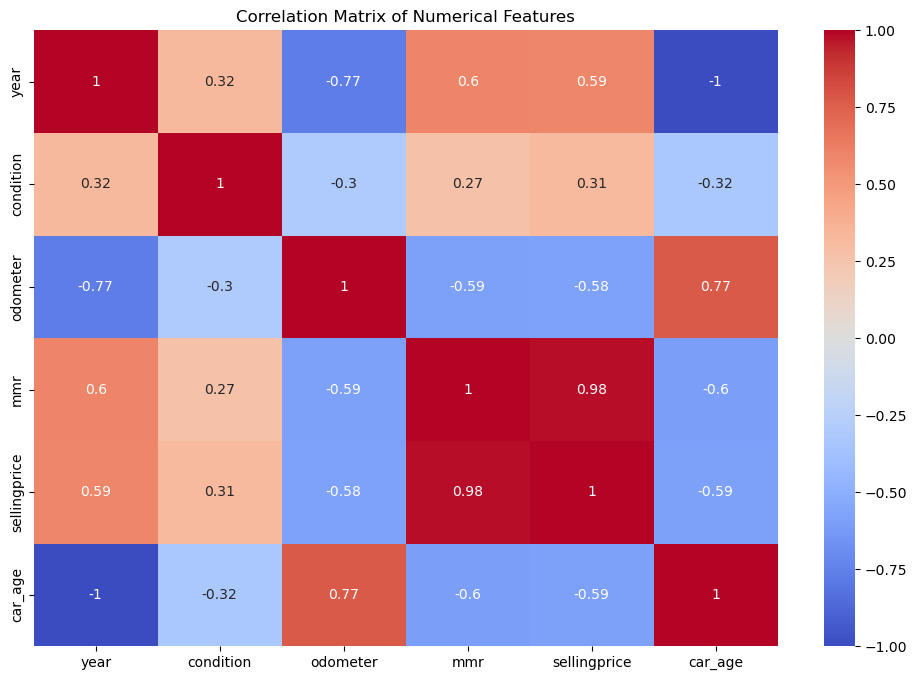

In [48]:
# Correlation of Numerical Columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
corr_matrix
# heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

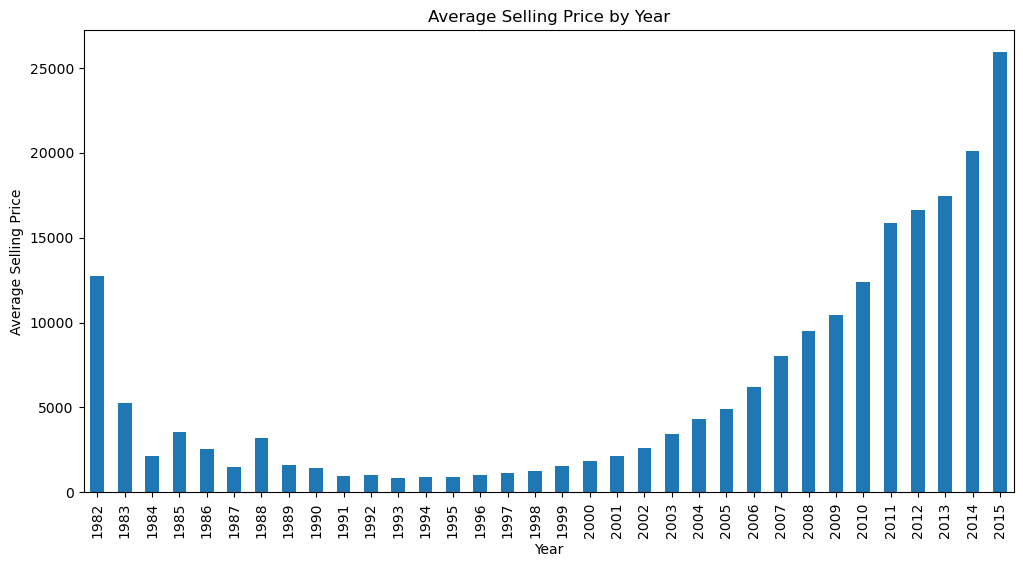

In [49]:
# Average Selling Price by Year (Bar Plot)
import matplotlib.pyplot as plt
# average price by year
avg_price_year = df.groupby('year')['sellingprice'].mean()
# bar chart
plt.figure(figsize=(12,6))
avg_price_year.plot(kind='bar')
plt.title("Average Selling Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Selling Price")
plt.show()

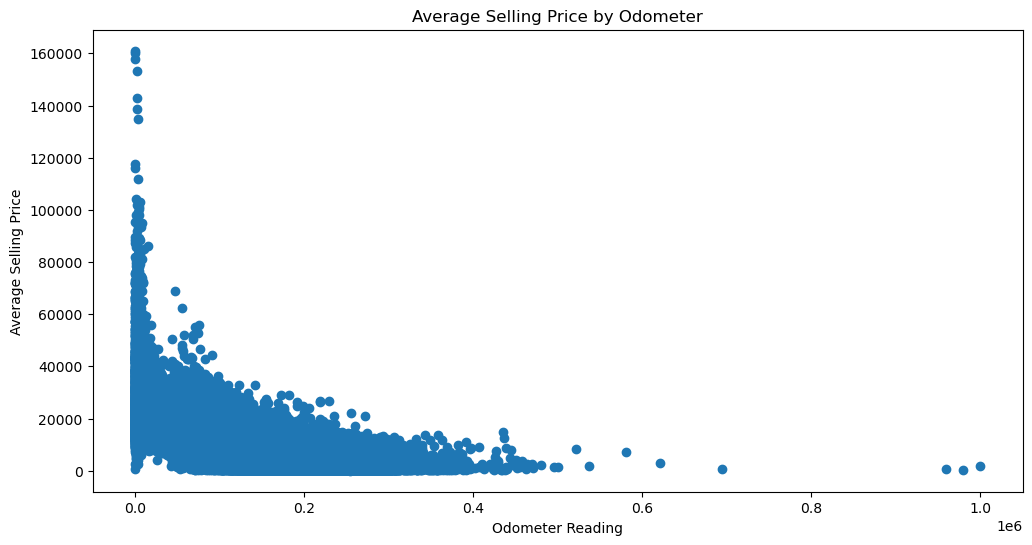

In [51]:
# Average Selling Price by Odometer
import matplotlib.pyplot as plt
avg_price_odometer = df.groupby('odometer')['sellingprice'].mean()
# scatter chart
plt.figure(figsize=(12,6))
plt.scatter(avg_price_odometer.index, avg_price_odometer.values)
plt.title("Average Selling Price by Odometer")
plt.xlabel("Odometer Reading")
plt.ylabel("Average Selling Price")
plt.show()

In [52]:
# Trend noticed from this graph
# As the odometer reading increases, the average selling price decreases sharply
# At very low odometer readings, the selling prices range widely

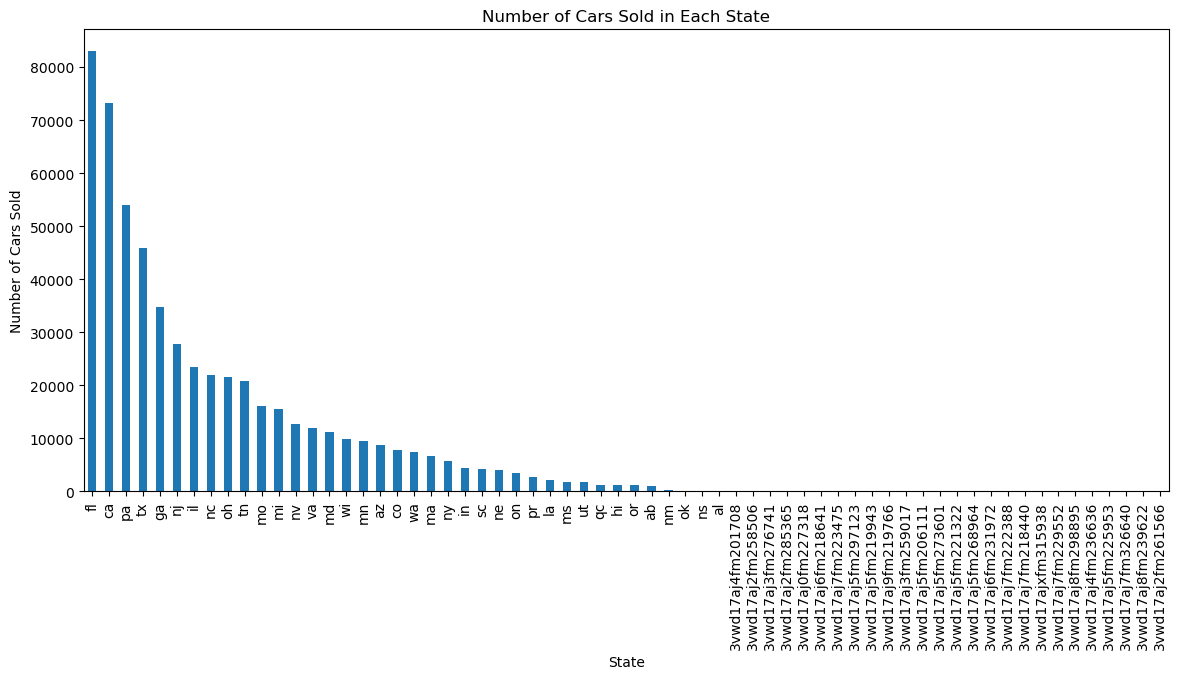

state
fl    82945
ca    73148
pa    53907
Name: count, dtype: int64

In [53]:
# Number of Cars Sold per State
import matplotlib.pyplot as plt
# cars sold per state
state_counts = df['state'].value_counts()
# bar chart
plt.figure(figsize=(14,6))
state_counts.plot(kind='bar')
plt.title("Number of Cars Sold in Each State")
plt.xlabel("State")
plt.ylabel("Number of Cars Sold")
plt.show()
# top 3 highest selling states
top_3_states = state_counts.head(3)
top_3_states

C:\Users\Sunil\AppData\Local\Temp\ipykernel_2748\3243965977.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_condition = df.groupby('condition_range')['sellingprice'].mean()


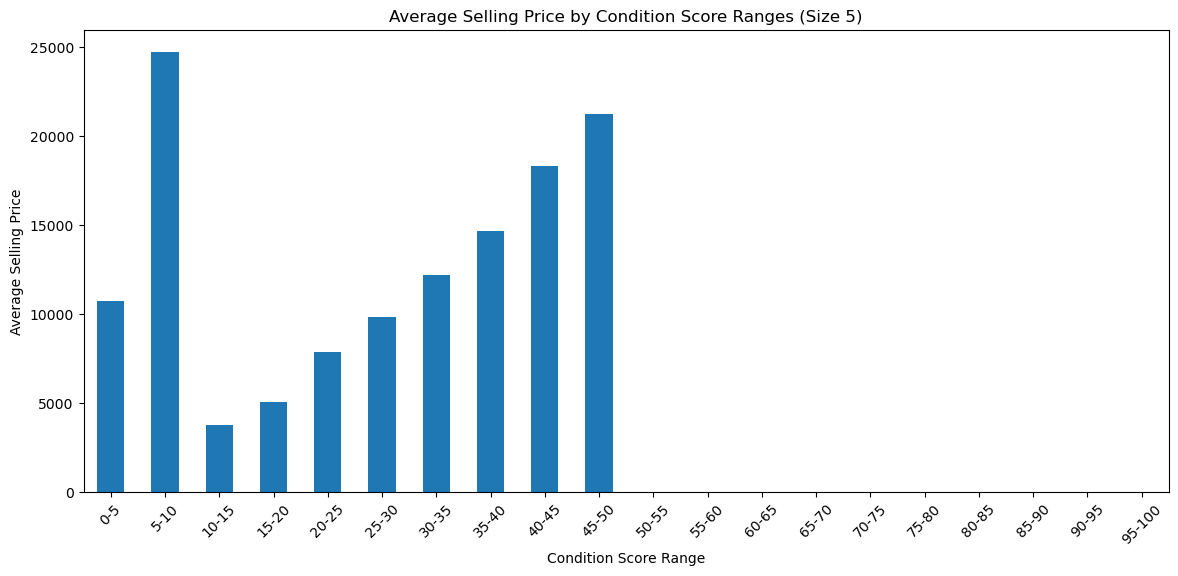

In [59]:
# average selling price by condition score ranges of size 5
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# ranges of size 5 (0–5, 5–10, 10–15,..... )
df['condition_range'] = pd.cut(
df['condition'],
bins=np.arange(0, 105, 5),
right=False,
labels=[f"{i}-{i+5}" for i in range(0, 100, 5)])
# average selling price per condition range
avg_price_by_condition = df.groupby('condition_range')['sellingprice'].mean()
# bar graph
plt.figure(figsize=(14,6))
avg_price_by_condition.plot(kind='bar')
plt.title("Average Selling Price by Condition Score Ranges (Size 5)")
plt.xlabel("Condition Score Range")
plt.ylabel("Average Selling Price")
plt.xticks(rotation=45)
plt.show()

In [67]:
# Insights
# As the condition score increases, the average selling price also increases
# Cars with condition scores between 0–30 have the lowest average selling prices
# Vehicles in the 40–70 range have moderate selling prices
# High-Condition Cars Deliver Maximum Value

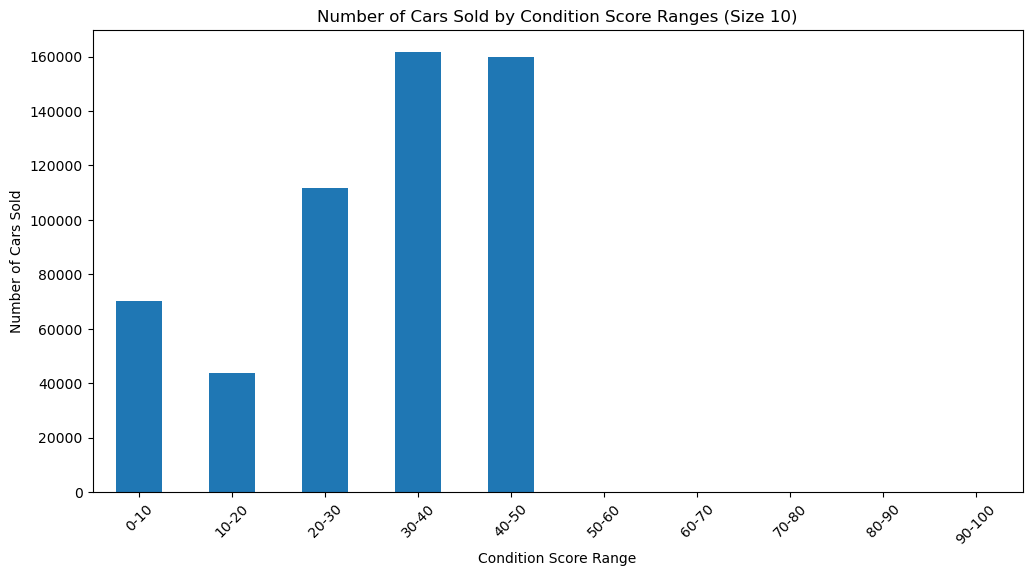

In [60]:
# Number of Cars Sold by Condition Ranges of Size 10
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create condition ranges of size 10 (0–10, 10–20, …, 90–100)
df['condition_range_10'] = pd.cut(
df['condition'],
bins=np.arange(0, 110, 10),
right=False,
labels=[f"{i}-{i+10}" for i in range(0, 100, 10)])
# number of cars sold in each range
condition_counts = df['condition_range_10'].value_counts().sort_index()
# bar graph
plt.figure(figsize=(12,6))
condition_counts.plot(kind='bar')
plt.title("Number of Cars Sold by Condition Score Ranges (Size 10)")
plt.xlabel("Condition Score Range")
plt.ylabel("Number of Cars Sold")
plt.xticks(rotation=45)
plt.show()

In [68]:
# Insights
# The market has a large supply of moderately used vehicles, which are common for resale.
# Very low-condition cars (0–20) are the least sold.
# High-condition cars (80–100) are fewer but still notable.
# buyers look for balance between price and condition, avoiding both extremes.

<Figure size 1400x600 with 0 Axes>

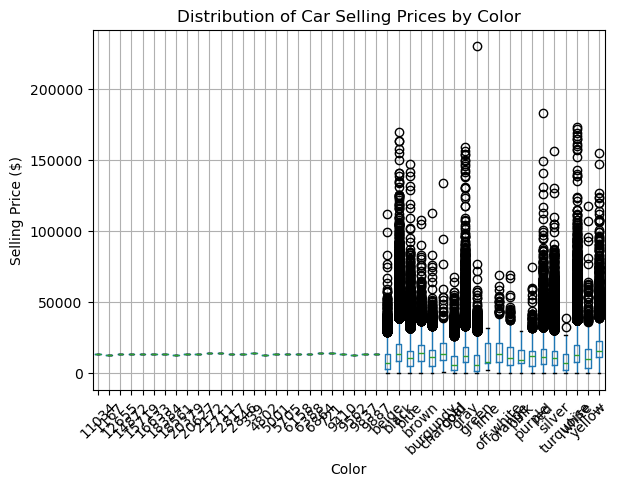

In [61]:
# Box Plot of Selling Prices
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
df.boxplot(column='sellingprice', by='color', rot=45)
plt.title("Distribution of Car Selling Prices by Color")
plt.suptitle("")  # remove default title
plt.xlabel("Color")
plt.ylabel("Selling Price ($)")
plt.show()

In [63]:
# Insights
# many points above $100,000 and even up to $200,000+.
# It indicates luxury or exotic vehicles mixed with regular cars, heavily stretching the plot upward.
# The median selling price Is Similar Across Most Colors.
# The Current Plot Is Hard to Interpret Due to Massive Outliers so we need to remove outliers.

In [64]:
Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)
IQR = Q3 - Q1
# Filter out outliers
df_no_outliers = df[(df['sellingprice'] >= Q1 - 1.5 * IQR) &
(df['sellingprice'] <= Q3 + 1.5 * IQR)]

<Figure size 1400x600 with 0 Axes>

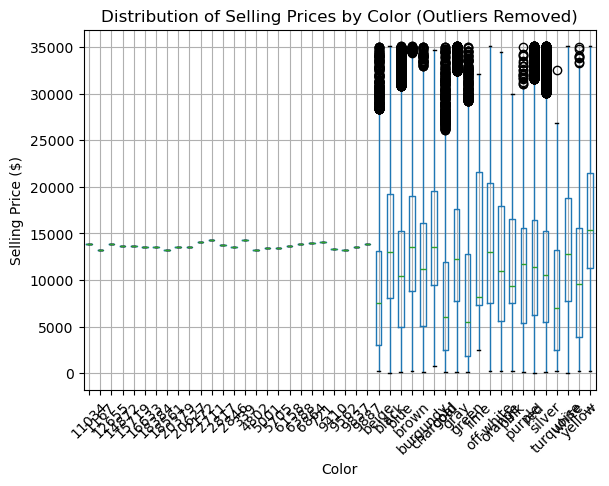

In [65]:
plt.figure(figsize=(14,6))
df_no_outliers.boxplot(column='sellingprice', by='color', rot=45)
plt.title("Distribution of Selling Prices by Color (Outliers Removed)")
plt.suptitle("")
plt.xlabel("Color")
plt.ylabel("Selling Price ($)")
plt.show()